### *Defining Graphic Function*

In [1]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

### Question 1 (Use yfinance to Extract Stock Data)

In [2]:
%pip install yfinance requests

Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf
import requests

# Step 1: Create ticker object
tesla = yf.Ticker("TSLA")

# Step 2: Extract historical stock data
tesla_data = tesla.history(period="max")

# Step 3: Reset index and display first 5 rows
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


### Question 2 (Use Webscraping to Extract Tesla Revenue Data)

**Note: For step 3, Here are the step-by-step instructions:**



1. Create an Empty DataFrame
2. Find the Relevant Table
3. Check for the Tesla Quarterly Revenue Table
4. Iterate Through Rows in the Table Body
5. Extract Data from Columns
6. Append Data to the DataFrame

In [4]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# Step 1: Download webpage
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text

# Step 2: Parse HTML data
soup = BeautifulSoup(html_data, "html.parser")

# Step 3: Extract Tesla Quarterly Revenue table using BeautifulSoup
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# Find the second table (Tesla Quarterly Revenue)
tables = soup.find_all("table")
for row in tables[1].find_all("tr"):
    cols = row.find_all("td")
    if cols:
        date = cols[0].text.strip()
        revenue = cols[1].text.strip()
        tesla_revenue = pd.concat(
            [
                tesla_revenue,
                pd.DataFrame([{"Date": date, "Revenue": revenue}]),
            ],
            ignore_index=True,
        )

# Step 4: Clean Revenue column
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(
    r"[\$,]", "", regex=True
)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

# Step 5: Display last 5 rows
tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


### Question 3 (Use yfinance to Extract GameStop Stock Data)

In [5]:
# Step 1: Create ticker object for GameStop
gme = yf.Ticker("GME")

# Step 2: Extract historical data
gme_data = gme.history(period="max")

# Step 3: Reset index and display first 5 rows
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


### Question 4 (Use Webscraping to Extract GME Revenue Data)

In [6]:
# Step 1: Download webpage
import requests
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url_gme).text

# Step 2: Parse HTML data
soup_gme = BeautifulSoup(html_data_2, "html.parser")

# Step 3: Extract GameStop Quarterly Revenue table
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

tables_gme = soup_gme.find_all("table")
for row in tables_gme[1].find_all("tr"):
    cols = row.find_all("td")
    if cols:
        date = cols[0].text.strip()
        revenue = cols[1].text.strip()
        gme_revenue = pd.concat(
            [gme_revenue, pd.DataFrame([{"Date": date, "Revenue": revenue}])],
            ignore_index=True,
        )

# Step 4: Clean Revenue column
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(
    r"[\$,]", "", regex=True
)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]
gme_revenue["Revenue"] = gme_revenue["Revenue"].astype(float)

# Step 5: Display last 5 rows
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667.0
58,2005-10-31,534.0
59,2005-07-31,416.0
60,2005-04-30,475.0
61,2005-01-31,709.0


### Question 5 (Plot Tesla Stock Graph)

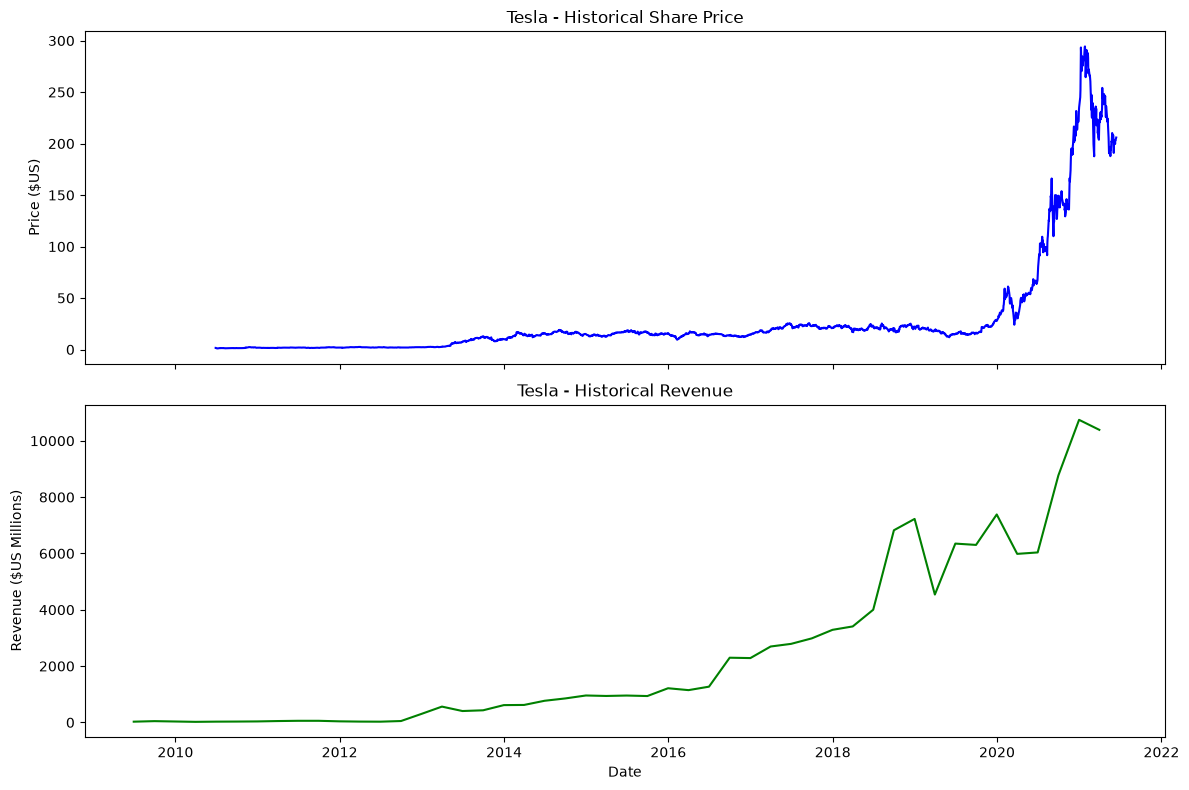

In [7]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

### Question 6 (Plot GameStop Stock Graph)

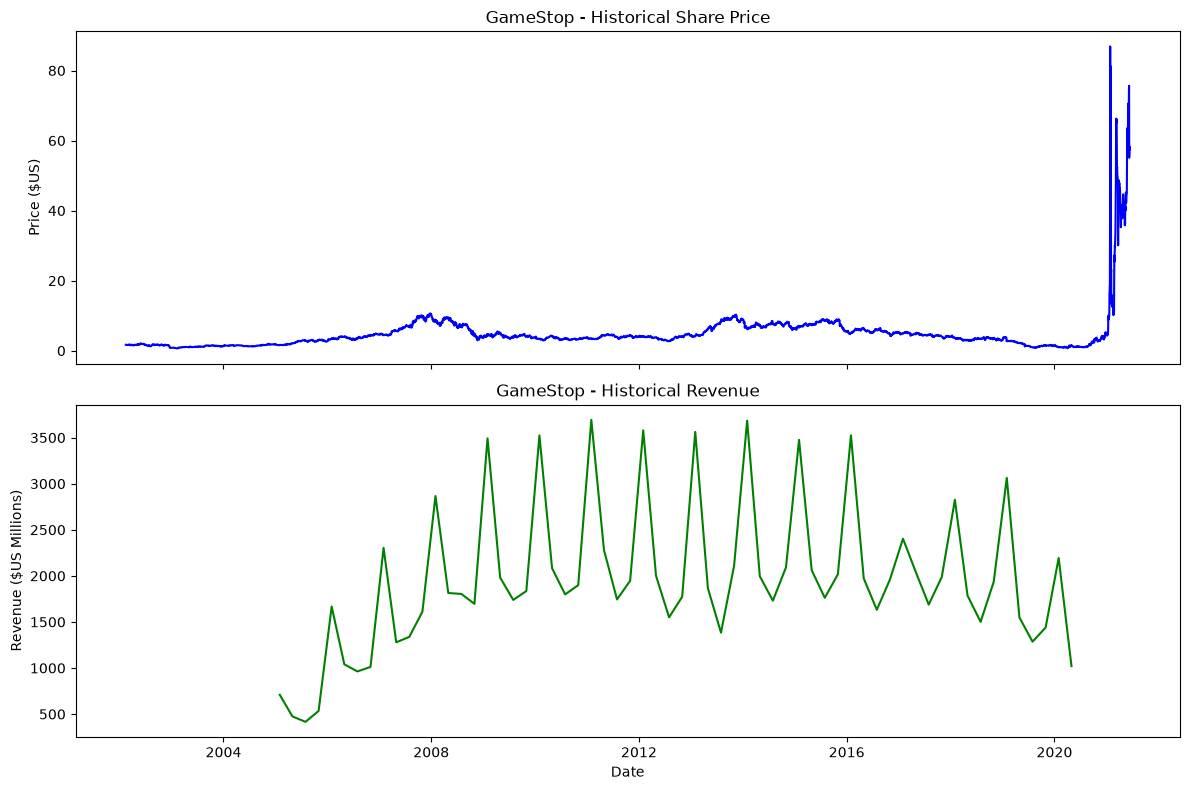

In [8]:
make_graph(gme_data, gme_revenue, 'GameStop')